# 1일차: 탐색적 데이터 분석(EDA) 및 베이스라인 모델 개발

## 학습 목표
- 제조업 데이터를 이용한 탐색적 데이터 분석(EDA) 수행
- Random Forest와 XGBoost를 활용한 머신러닝 예측 모델 구축
- 모델 성능 평가 및 Feature Importance 분석

---

## 데이터셋 소개: AI4I 2020 Predictive Maintenance Dataset

### 개요
이 데이터셋은 실제 밀링 머신을 모델링한 합성 데이터셋으로, 10,000개의 데이터 포인트와 14개의 특성으로 구성되어 있습니다.

### 특성 설명

**1. 식별자 및 제품 정보**
- `UDI`: 고유 식별자 (1~10000)
- `Product ID`: 제품 ID (L/M/H + 일련번호)
- `Type`: 제품 품질 유형
  - L (Low): 저품질, 전체의 50%
  - M (Medium): 중품질, 전체의 30%
  - H (High): 고품질, 전체의 20%

**2. 공정 파라미터**
- `Air temperature [K]`: 공기 온도, 300K 주변에 표준편차 2K로 정규화
- `Process temperature [K]`: 공정 온도, 공기 온도 + 10K에 표준편차 1K로 정규화
- `Rotational speed [rpm]`: 회전 속도, 2860W 파워 기반 계산
- `Torque [Nm]`: 토크, 평균 40Nm, 표준편차 10Nm의 정규분포
- `Tool wear [min]`: 도구 마모도, H/M/L 타입별로 5/3/2분씩 누적

**3. 고장 관련 특성**
- `Machine failure`: 기계 고장 여부 (0: 정상, 1: 고장)

### 고장 모드 (Failure Modes)

1. **TWF (Tool Wear Failure)**: 도구 마모 고장
   - 200-240분 사이에 도구 교체 또는 고장
   - 데이터셋에서 120회 발생 (교체 69회, 고장 51회)

2. **HDF (Heat Dissipation Failure)**: 열 방출 고장
   - 공기-공정 온도차 < 8.6K이고 회전속도 < 1380rpm일 때 발생
   - 115개 데이터 포인트에서 발생

3. **PWF (Power Failure)**: 전력 고장
   - 토크 × 회전속도(rad/s) = 필요 전력
   - 전력이 3500W 미만 또는 9000W 초과시 발생
   - 95회 발생

4. **OSF (Overstrain Failure)**: 과부하 고장
   - 도구 마모도 × 토크 > 11,000 min·Nm (L제품)
   - M제품: 12,000, H제품: 13,000 초과시 발생
   - 98개 데이터 포인트에서 발생

5. **RNF (Random Failure)**: 랜덤 고장
   - 각 공정당 0.1% 확률로 무작위 발생
   - 5개 데이터 포인트에서 발생

### 참고문헌
S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," 2020 Third International Conference on Artificial Intelligence for Industries (AI4I), 2020, pp. 69-74, doi: 10.1109/AI4I49448.2020.00023.

---

## 1. 라이브러리 Import 및 환경 설정

In [16]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [17]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")
import os
import pickle

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 머신러닝 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import xgboost as xgb

# 모델 저장용 폴더 생성
if not os.path.exists("models"):
    os.makedirs("models")
    print("📁 models 폴더가 생성되었습니다.")

print("모든 라이브러리가 성공적으로 로드되었습니다.")

모든 라이브러리가 성공적으로 로드되었습니다.


## 2. 데이터 로드 및 기본 정보 확인

In [18]:
# 데이터 로드
df = pd.read_csv("data/ai4i2020.csv")

# XGBoost 호환을 위한 컬럼명 변경 (대괄호 제거)
column_rename_map = {
    "Air temperature [K]": "Air_temperature_K",
    "Process temperature [K]": "Process_temperature_K",
    "Rotational speed [rpm]": "Rotational_speed_rpm",
    "Torque [Nm]": "Torque_Nm",
    "Tool wear [min]": "Tool_wear_min",
}

df.rename(columns=column_rename_map, inplace=True)

print("=== 데이터 기본 정보 ===")
print(f"데이터 크기: {df.shape}")
print(f"- 행(샘플) 수: {df.shape[0]:,}")
print(f"- 열(특성) 수: {df.shape[1]}")
print("\n⚠️ XGBoost 호환을 위해 컬럼명의 대괄호를 언더스코어로 변경했습니다.")
print("\n=== 데이터 샘플 (처음 5개) ===")
df.head()

=== 데이터 기본 정보 ===
데이터 크기: (10000, 14)
- 행(샘플) 수: 10,000
- 열(특성) 수: 14

⚠️ XGBoost 호환을 위해 컬럼명의 대괄호를 언더스코어로 변경했습니다.

=== 데이터 샘플 (처음 5개) ===


,UDI,Product ID,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [19]:
# 데이터 타입 및 결측값 확인
print("=== 데이터 정보 ===")
df.info()

print("\n=== 결측값 확인 ===")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✅ 결측값이 없습니다.")
else:
    print(missing_values[missing_values > 0])

=== 데이터 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UDI                    10000 non-null  int64  
 1   Product ID             10000 non-null  object 
 2   Type                   10000 non-null  object 
 3   Air_temperature_K      10000 non-null  float64
 4   Process_temperature_K  10000 non-null  float64
 5   Rotational_speed_rpm   10000 non-null  int64  
 6   Torque_Nm              10000 non-null  float64
 7   Tool_wear_min          10000 non-null  int64  
 8   Machine failure        10000 non-null  int64  
 9   TWF                    10000 non-null  int64  
 10  HDF                    10000 non-null  int64  
 11  PWF                    10000 non-null  int64  
 12  OSF                    10000 non-null  int64  
 13  RNF                    10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memor

## 3. 탐색적 데이터 분석 (EDA)

### 3.1 기술통계량 확인

In [20]:
# 수치형 변수의 기술통계
print("=== 수치형 변수 기술통계 ===")
numeric_cols = [
    "Air_temperature_K",
    "Process_temperature_K",
    "Rotational_speed_rpm",
    "Torque_Nm",
    "Tool_wear_min",
]
df[numeric_cols].describe().round(2)

=== 수치형 변수 기술통계 ===


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


### 3.2 목표 변수(Machine Failure) 분포

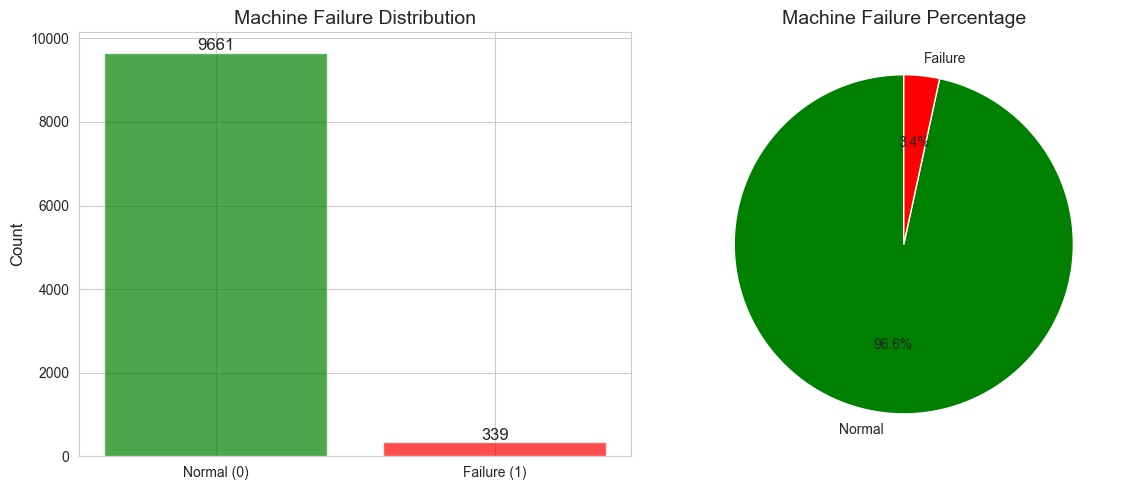

정상: 9,661건 (96.61%)
고장: 339건 (3.39%)

⚠️ 클래스 불균형 비율: 1:28.5


In [21]:
# # Machine Failure 분포
failure_counts = df["Machine failure"].value_counts()
failure_percentage = df["Machine failure"].value_counts(normalize=True) * 100


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # 막대 그래프
axes[0].bar(
    ["Normal (0)", "Failure (1)"],
    failure_counts.values,
    color=["green", "red"],
    alpha=0.7,
)
axes[0].set_title("Machine Failure Distribution", fontsize=14)
axes[0].set_ylabel("Count", fontsize=12)
for i, v in enumerate(failure_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=12)

# # 파이 차트
axes[1].pie(
    failure_counts.values,
    labels=["Normal", "Failure"],
    autopct="%1.1f%%",
    colors=["green", "red"],
    startangle=90,
)
axes[1].set_title("Machine Failure Percentage", fontsize=14)

plt.tight_layout()
plt.show()

print(f"정상: {failure_counts[0]:,}건 ({failure_percentage[0]:.2f}%)")
print(f"고장: {failure_counts[1]:,}건 ({failure_percentage[1]:.2f}%)")
print(f"\n⚠️ 클래스 불균형 비율: 1:{failure_counts[0]/failure_counts[1]:.1f}")

### 3.3 고장 유형별 분석

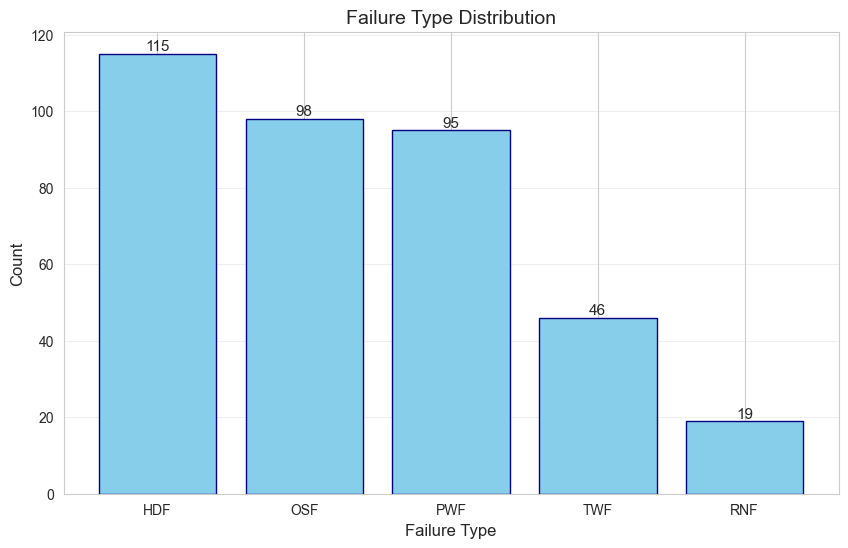

=== 고장 유형별 발생 건수 ===
HDF: 115건
OSF: 98건
PWF: 95건
TWF: 46건
RNF: 19건


In [22]:
# 고장 유형별 발생 건수
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]
failure_type_counts = df[failure_types].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    failure_type_counts.index,
    failure_type_counts.values,
    color="skyblue",
    edgecolor="navy",
)
plt.title("Failure Type Distribution", fontsize=14)
plt.xlabel("Failure Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.grid(axis="y", alpha=0.3)
plt.show()

print("=== 고장 유형별 발생 건수 ===")
for ft in failure_type_counts.index:
    print(f"{ft}: {failure_type_counts[ft]}건")

### 3.4 제품 타입별 분석

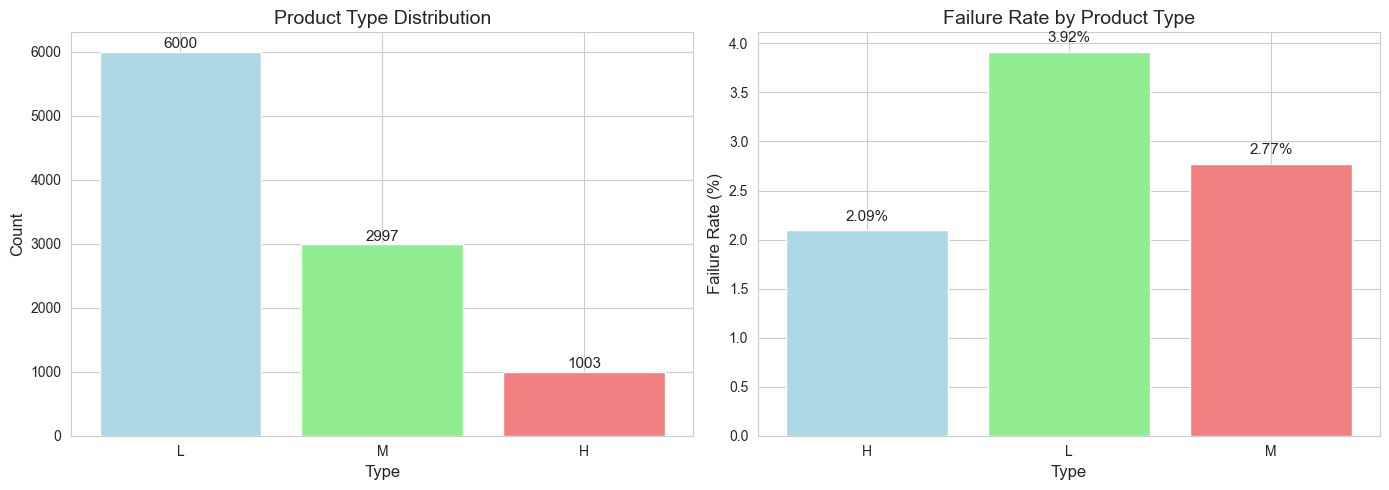

=== 제품 타입별 통계 ===
Type L: 6,000개 (고장률: 3.92%)
Type M: 2,997개 (고장률: 2.77%)
Type H: 1,003개 (고장률: 2.09%)


In [23]:
# 제품 타입별 분포 및 고장률
type_counts = df["Type"].value_counts()
type_failure_rate = df.groupby("Type")["Machine failure"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 제품 타입별 분포
axes[0].bar(
    type_counts.index,
    type_counts.values,
    color=["lightblue", "lightgreen", "lightcoral"],
)
axes[0].set_title("Product Type Distribution", fontsize=14)
axes[0].set_xlabel("Type", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
for i, (idx, v) in enumerate(type_counts.items()):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=11)

# 제품 타입별 고장률
axes[1].bar(
    type_failure_rate.index,
    type_failure_rate.values,
    color=["lightblue", "lightgreen", "lightcoral"],
)
axes[1].set_title("Failure Rate by Product Type", fontsize=14)
axes[1].set_xlabel("Type", fontsize=12)
axes[1].set_ylabel("Failure Rate (%)", fontsize=12)
for i, (idx, v) in enumerate(type_failure_rate.items()):
    axes[1].text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

print("=== 제품 타입별 통계 ===")
for type_name in type_counts.index:
    print(
        f"Type {type_name}: {type_counts[type_name]:,}개 (고장률: {type_failure_rate[type_name]:.2f}%)"
    )

### 3.5 수치형 변수 분포

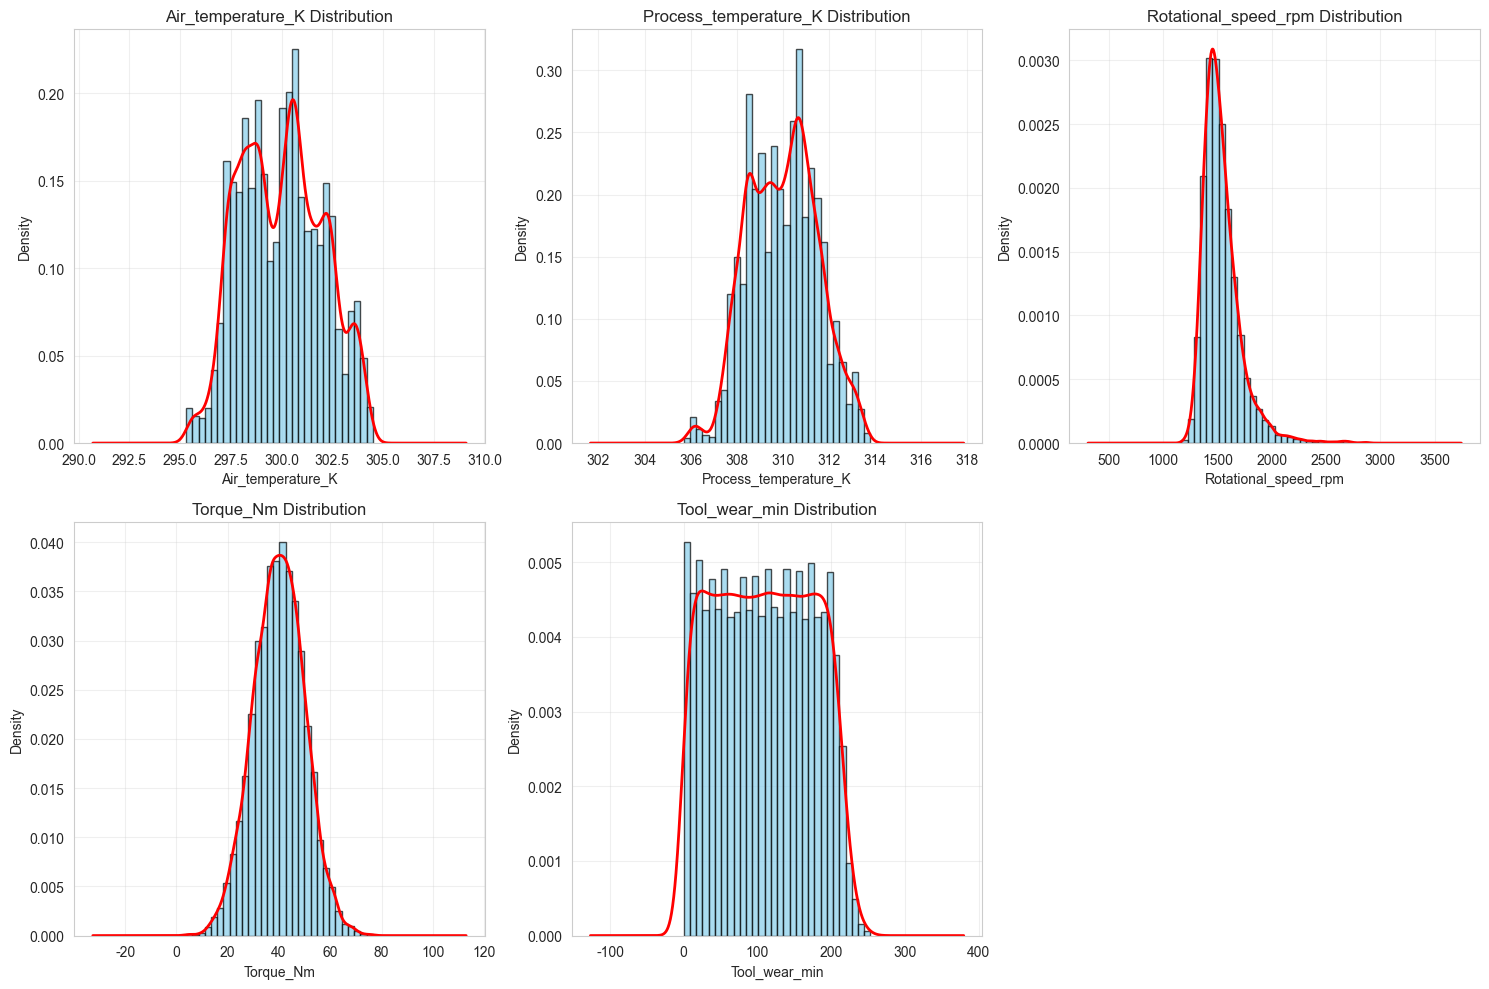

In [24]:
# 수치형 변수의 분포 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    # 히스토그램과 KDE
    axes[idx].hist(
        df[col], bins=30, density=True, alpha=0.7, color="skyblue", edgecolor="black"
    )
    df[col].plot.kde(ax=axes[idx], color="red", linewidth=2)
    axes[idx].set_title(f"{col} Distribution", fontsize=12)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel("Density", fontsize=10)
    axes[idx].grid(alpha=0.3)

# 빈 subplot 제거
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 3.6 상관관계 분석

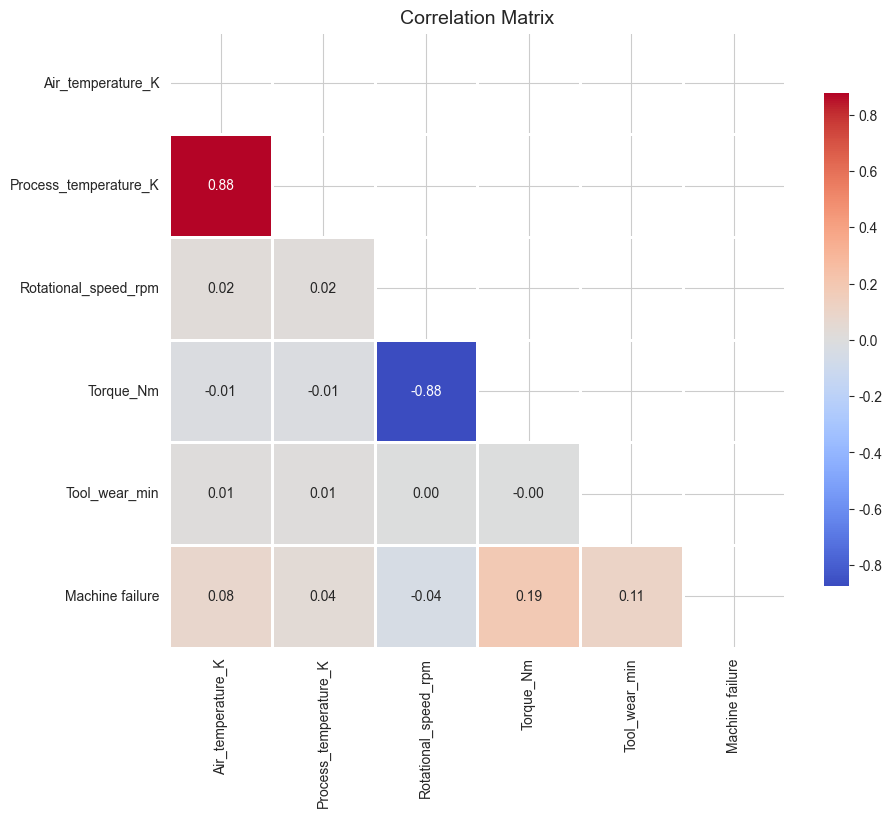

=== Machine Failure와의 상관관계 ===
Torque_Nm: 0.191
Tool_wear_min: 0.105
Air_temperature_K: 0.083
Process_temperature_K: 0.036
Rotational_speed_rpm: -0.044


In [25]:
# 상관관계 행렬 계산
correlation_cols = numeric_cols + ["Machine failure"]
corr_matrix = df[correlation_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Machine failure와의 상관관계
print("=== Machine Failure와의 상관관계 ===")
failure_corr = (
    corr_matrix["Machine failure"].drop("Machine failure").sort_values(ascending=False)
)
for feature, corr in failure_corr.items():
    print(f"{feature}: {corr:.3f}")

### 3.7 고장 vs 정상 상태의 특성 비교

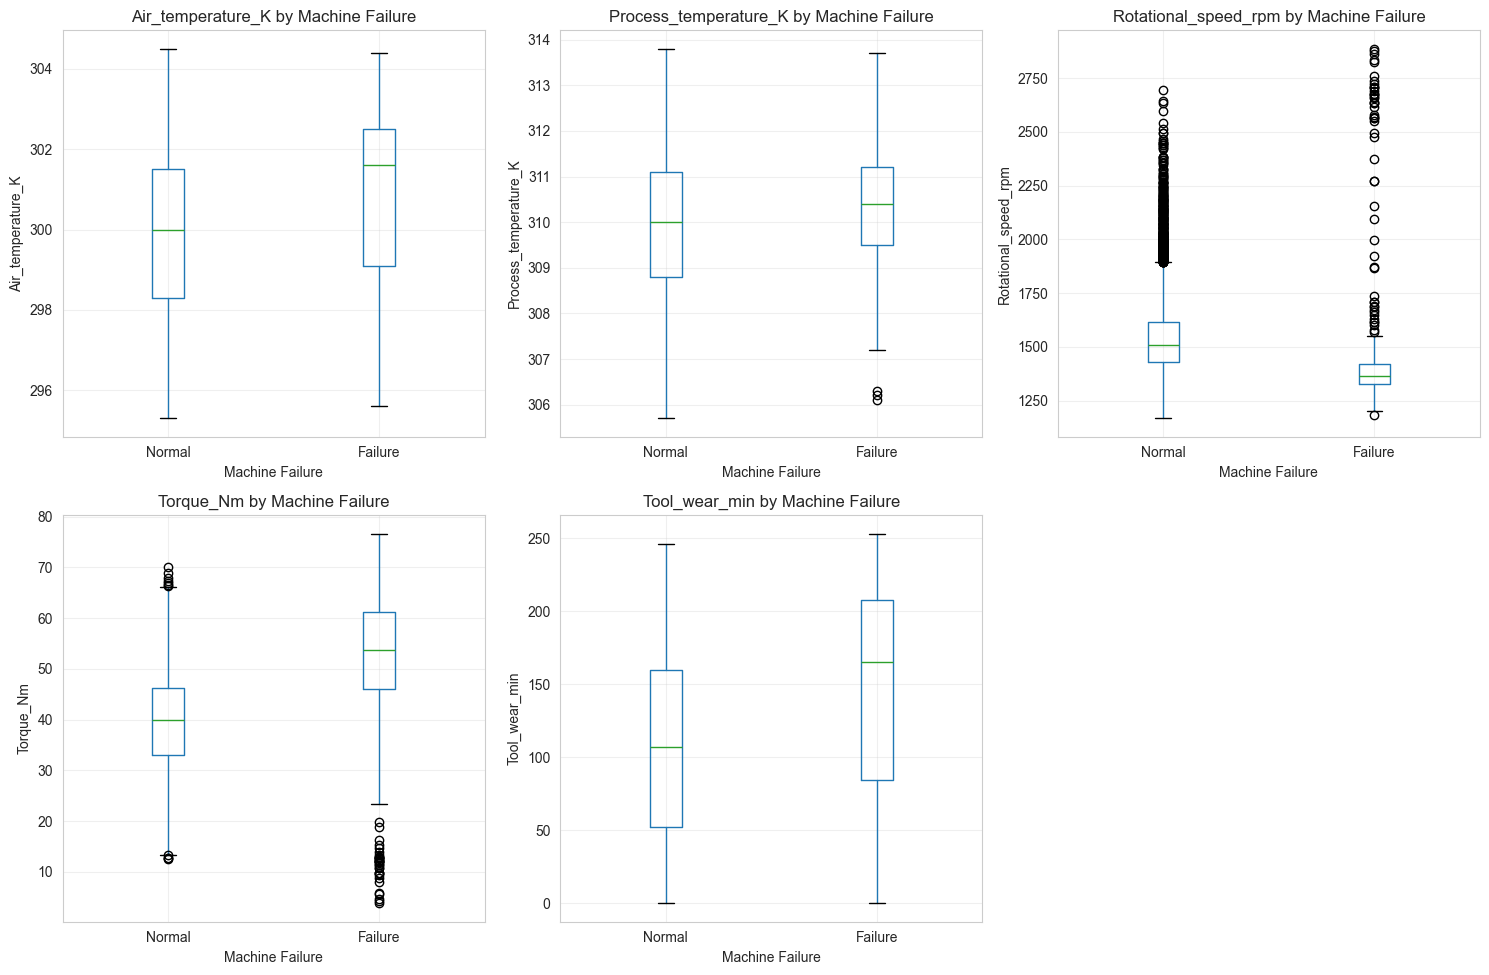

In [26]:
# 고장 여부에 따른 특성 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    # Box plot
    df.boxplot(column=col, by="Machine failure", ax=axes[idx])
    axes[idx].set_title(f"{col} by Machine Failure", fontsize=12)
    axes[idx].set_xlabel("Machine Failure", fontsize=10)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(alpha=0.3)
    plt.sca(axes[idx])
    plt.xticks([1, 2], ["Normal", "Failure"])

fig.delaxes(axes[5])
plt.suptitle("")  # 기본 제목 제거
plt.tight_layout()
plt.show()

## 4. 데이터 전처리

### 4.1 특성 선택 및 인코딩

In [27]:
# 불필요한 컬럼 제거
# UDI와 Product ID는 식별자이므로 제거
# 개별 고장 유형(TWF, HDF, PWF, OSF, RNF)도 제거 (타겟 변수와 직접적 관련)
features_to_use = [
    "Type",
    "Air_temperature_K",
    "Process_temperature_K",
    "Rotational_speed_rpm",
    "Torque_Nm",
    "Tool_wear_min",
]
target = "Machine failure"

X = df[features_to_use].copy()
y = df[target].copy()

print("사용할 특성들:", features_to_use)
print("타겟 변수:", target)

사용할 특성들: ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']
타겟 변수: Machine failure


In [28]:
# Type 컬럼 인코딩 (Label Encoding)
le = LabelEncoder()
X["Type_encoded"] = le.fit_transform(X["Type"])
X = X.drop("Type", axis=1)

print("Type 인코딩 결과:")
for i, type_val in enumerate(le.classes_):
    print(f"  {type_val} -> {i}")

print("\n전처리 후 특성 shape:", X.shape)

Type 인코딩 결과:
  H -> 0
  L -> 1
  M -> 2

전처리 후 특성 shape: (10000, 6)


### 4.2 데이터 분할 및 스케일링

In [29]:
# Train/Test 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== 데이터 분할 결과 ===")
print(f"학습 데이터: {X_train.shape[0]:,}개")
print(f"테스트 데이터: {X_test.shape[0]:,}개")
print(f"\n학습 데이터 고장률: {y_train.mean():.2%}")
print(f"테스트 데이터 고장률: {y_test.mean():.2%}")

=== 데이터 분할 결과 ===
학습 데이터: 8,000개
테스트 데이터: 2,000개

학습 데이터 고장률: 3.39%
테스트 데이터 고장률: 3.40%


In [30]:
# 특성 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# DataFrame으로 변환 (특성명 유지)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✅ 데이터 스케일링 완료")
print("\n스케일링 후 통계:")
print(X_train_scaled.describe().round(2))

✅ 데이터 스케일링 완료

스케일링 후 통계:
       Air_temperature_K  Process_temperature_K  Rotational_speed_rpm  \
count            8000.00                8000.00               8000.00   
mean                0.00                   0.00                  0.00   
std                 1.00                   1.00                  1.00   
min                -2.36                  -2.91                 -2.05   
25%                -0.85                  -0.82                 -0.65   
50%                 0.05                   0.06                 -0.20   
75%                 0.75                   0.74                  0.41   
max                 2.25                   2.56                  7.44   

       Torque_Nm  Tool_wear_min  Type_encoded  
count    8000.00        8000.00       8000.00  
mean       -0.00          -0.00         -0.00  
std         1.00           1.00          1.00  
min        -3.61          -1.69         -2.01  
25%        -0.68          -0.86         -0.33  
50%         0.01          -0

# 특성 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일러 저장 (2일차에서 동일한 스케일링 적용을 위해)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("📁 스케일러가 models/scaler.pkl로 저장되었습니다.")

# DataFrame으로 변환 (특성명 유지)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✅ 데이터 스케일링 완료")
print("\n스케일링 후 통계:")
print(X_train_scaled.describe().round(2))

In [31]:
# Random Forest 모델 생성 및 학습
rf_model = RandomForestClassifier(
    n_estimators=100,  # 트리 개수
    max_depth=10,  # 트리 최대 깊이
    min_samples_split=5,  # 노드 분할 최소 샘플 수
    min_samples_leaf=2,  # 리프 노드 최소 샘플 수
    random_state=42,
    n_jobs=-1,  # 모든 CPU 코어 사용
)

print("Random Forest 모델 학습 중...")
rf_model.fit(X_train_scaled, y_train)
print("✅ 학습 완료!")

Random Forest 모델 학습 중...
✅ 학습 완료!


In [32]:
# Random Forest 모델 생성 및 학습
import pickle

rf_model = RandomForestClassifier(
    n_estimators=100,  # 트리 개수
    max_depth=10,  # 트리 최대 깊이
    min_samples_split=5,  # 노드 분할 최소 샘플 수
    min_samples_leaf=2,  # 리프 노드 최소 샘플 수
    random_state=42,
    n_jobs=-1,  # 모든 CPU 코어 사용
)

print("Random Forest 모델 학습 중...")
rf_model.fit(X_train_scaled, y_train)
print("✅ 학습 완료!")

# 모델 저장
with open("models/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("📁 Random Forest 모델이 models/rf_model.pkl로 저장되었습니다.")

Random Forest 모델 학습 중...
✅ 학습 완료!
📁 Random Forest 모델이 models/rf_model.pkl로 저장되었습니다.


In [33]:
# 예측
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)


# 성능 메트릭 계산 함수
def calculate_metrics(y_true, y_pred, model_name):
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }
    return metrics


# Random Forest 성능 평가
rf_train_metrics = calculate_metrics(y_train, rf_train_pred, "RF_Train")
rf_test_metrics = calculate_metrics(y_test, rf_test_pred, "RF_Test")

print("=== Random Forest 성능 평가 ===")
print("\n[훈련 데이터]")
for metric, value in rf_train_metrics.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

print("\n[테스트 데이터]")
for metric, value in rf_test_metrics.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

=== Random Forest 성능 평가 ===

[훈련 데이터]
Accuracy  : 0.9926
Precision : 0.9907
Recall    : 0.7897
F1-Score  : 0.8789

[테스트 데이터]
Accuracy  : 0.9825
Precision : 0.9024
Recall    : 0.5441
F1-Score  : 0.6789


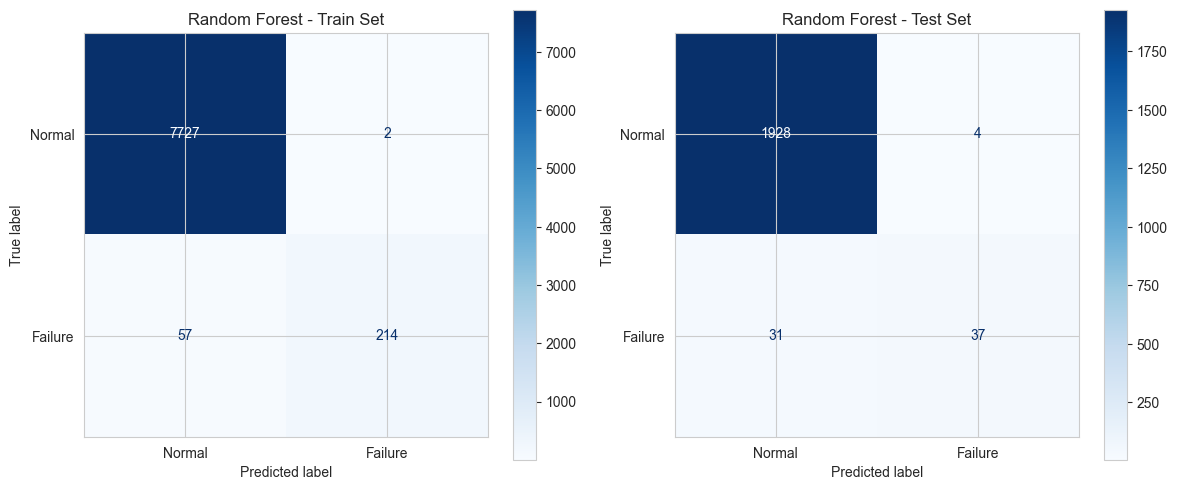

In [34]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 훈련 데이터
cm_train = confusion_matrix(y_train, rf_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train, display_labels=["Normal", "Failure"]
)
disp_train.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Random Forest - Train Set", fontsize=12)

# 테스트 데이터
cm_test = confusion_matrix(y_test, rf_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test, display_labels=["Normal", "Failure"]
)
disp_test.plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Random Forest - Test Set", fontsize=12)

plt.tight_layout()
plt.show()

### 5.3 Feature Importance

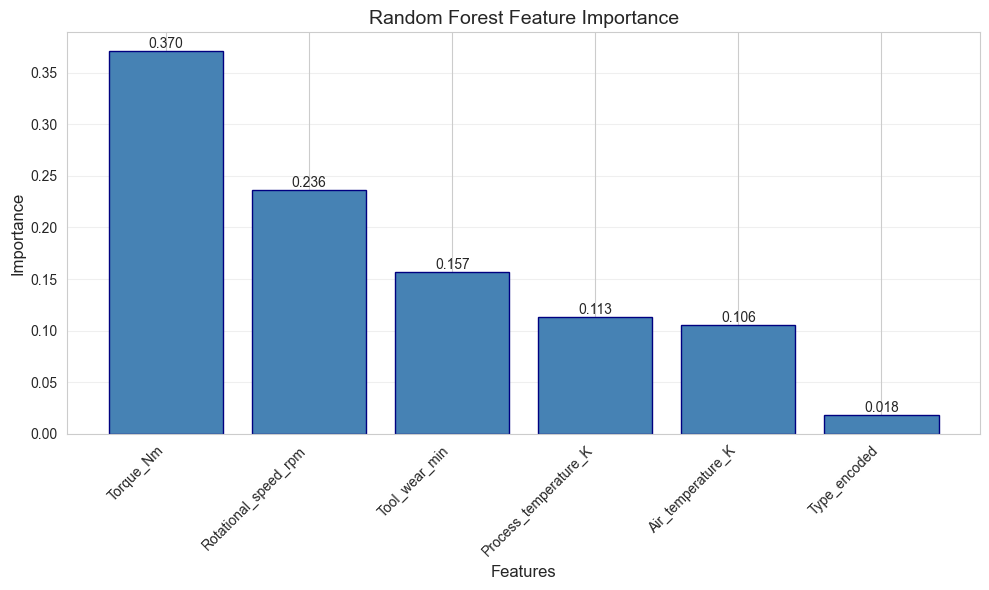

=== Feature Importance 순위 ===
Torque_Nm                : 0.3705
Rotational_speed_rpm     : 0.2359
Tool_wear_min            : 0.1569
Process_temperature_K    : 0.1130
Air_temperature_K        : 0.1059
Type_encoded             : 0.0179


In [35]:
# Random Forest Feature Importance
rf_feature_importance = pd.DataFrame(
    {"feature": X_train.columns, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    rf_feature_importance["feature"],
    rf_feature_importance["importance"],
    color="steelblue",
    edgecolor="navy",
)
plt.title("Random Forest Feature Importance", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.xticks(rotation=45, ha="right")

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Feature Importance 순위 ===")
for idx, row in rf_feature_importance.iterrows():
    print(f"{row['feature']:25s}: {row['importance']:.4f}")

## 6. XGBoost 모델

### 6.1 모델 학습

In [36]:
# XGBoost 모델 생성 및 학습
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="binary:logistic",
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
)

print("XGBoost 모델 학습 중...")
xgb_model.fit(X_train_scaled, y_train)
print("✅ 학습 완료!")

# 모델 저장
with open("models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
print("📁 XGBoost 모델이 models/xgb_model.pkl로 저장되었습니다.")

XGBoost 모델 학습 중...
✅ 학습 완료!
📁 XGBoost 모델이 models/xgb_model.pkl로 저장되었습니다.


In [37]:
# 예측
xgb_train_pred = xgb_model.predict(X_train_scaled)
xgb_test_pred = xgb_model.predict(X_test_scaled)

# XGBoost 성능 평가
xgb_train_metrics = calculate_metrics(y_train, xgb_train_pred, "XGB_Train")
xgb_test_metrics = calculate_metrics(y_test, xgb_test_pred, "XGB_Test")

print("=== XGBoost 성능 평가 ===")
print("\n[훈련 데이터]")
for metric, value in xgb_train_metrics.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

print("\n[테스트 데이터]")
for metric, value in xgb_test_metrics.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

=== XGBoost 성능 평가 ===

[훈련 데이터]
Accuracy  : 0.9960
Precision : 0.9959
Recall    : 0.8856
F1-Score  : 0.9375

[테스트 데이터]
Accuracy  : 0.9885
Precision : 0.9245
Recall    : 0.7206
F1-Score  : 0.8099


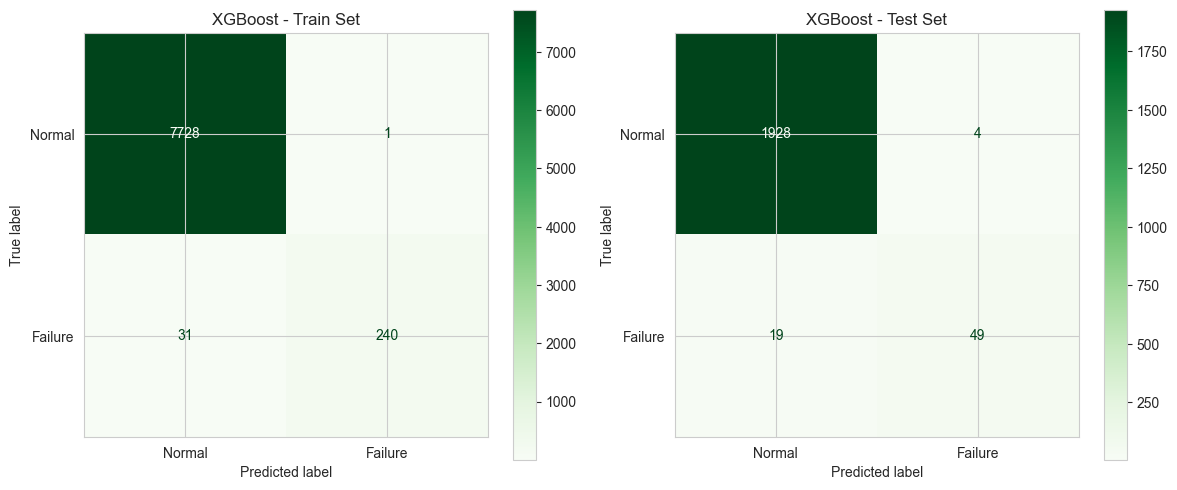

In [38]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 훈련 데이터
cm_train = confusion_matrix(y_train, xgb_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train, display_labels=["Normal", "Failure"]
)
disp_train.plot(ax=axes[0], cmap="Greens")
axes[0].set_title("XGBoost - Train Set", fontsize=12)

# 테스트 데이터
cm_test = confusion_matrix(y_test, xgb_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test, display_labels=["Normal", "Failure"]
)
disp_test.plot(ax=axes[1], cmap="Greens")
axes[1].set_title("XGBoost - Test Set", fontsize=12)

plt.tight_layout()
plt.show()

### 6.3 Feature Importance

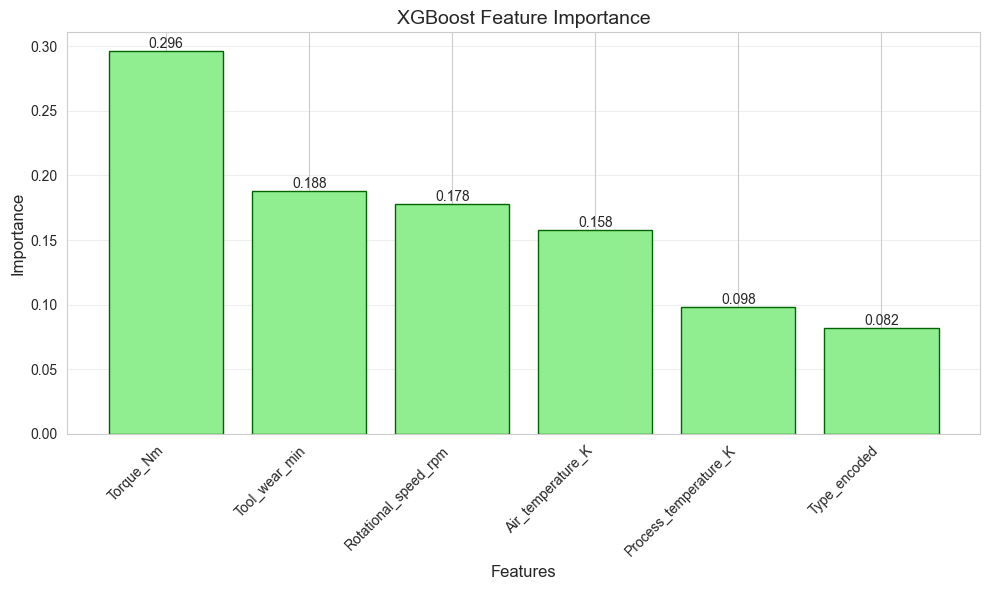

=== Feature Importance 순위 ===
Torque_Nm                : 0.2958
Tool_wear_min            : 0.1878
Rotational_speed_rpm     : 0.1780
Air_temperature_K        : 0.1580
Process_temperature_K    : 0.0981
Type_encoded             : 0.0822


In [39]:
# XGBoost Feature Importance
xgb_feature_importance = pd.DataFrame(
    {"feature": X_train.columns, "importance": xgb_model.feature_importances_}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    xgb_feature_importance["feature"],
    xgb_feature_importance["importance"],
    color="lightgreen",
    edgecolor="darkgreen",
)
plt.title("XGBoost Feature Importance", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.xticks(rotation=45, ha="right")

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Feature Importance 순위 ===")
for idx, row in xgb_feature_importance.iterrows():
    print(f"{row['feature']:25s}: {row['importance']:.4f}")

## 7. 모델 성능 비교

### 7.1 성능 메트릭 비교

In [40]:
# 성능 비교 데이터프레임 생성
performance_comparison = pd.DataFrame([rf_test_metrics, xgb_test_metrics])

# 모델명 정리
performance_comparison["Model"] = ["Random Forest", "XGBoost"]
performance_comparison = performance_comparison.set_index("Model")

print("=== 모델 성능 비교 (테스트 데이터) ===")
print(performance_comparison.round(4))

# 최고 성능 모델
best_model = performance_comparison["F1-Score"].idxmax()
best_f1 = performance_comparison["F1-Score"].max()
print(f"\n🏆 최고 성능 모델: {best_model} (F1-Score: {best_f1:.4f})")

=== 모델 성능 비교 (테스트 데이터) ===
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest    0.9825     0.9024  0.5441    0.6789
XGBoost          0.9885     0.9245  0.7206    0.8099

🏆 최고 성능 모델: XGBoost (F1-Score: 0.8099)


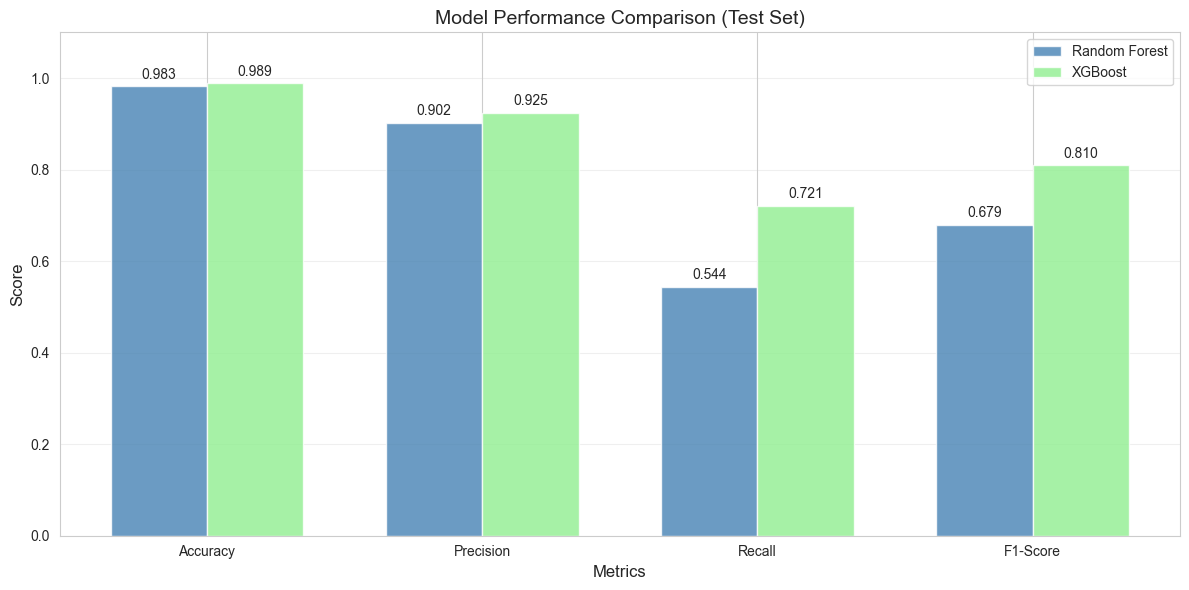

In [41]:
# 성능 메트릭 시각화
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Random Forest
rf_values = [rf_test_metrics[m] for m in metrics]
bars1 = ax.bar(
    x - width / 2, rf_values, width, label="Random Forest", color="steelblue", alpha=0.8
)

# XGBoost
xgb_values = [xgb_test_metrics[m] for m in metrics]
bars2 = ax.bar(
    x + width / 2, xgb_values, width, label="XGBoost", color="lightgreen", alpha=0.8
)

# 그래프 설정
ax.set_xlabel("Metrics", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison (Test Set)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis="y", alpha=0.3)

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()
plt.show()

### 7.2 Feature Importance 비교

In [42]:
# Feature Importance 비교
importance_comparison = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Random Forest": rf_model.feature_importances_,
        "XGBoost": xgb_model.feature_importances_,
    }
)

# 평균 중요도로 정렬
importance_comparison["Average"] = importance_comparison[
    ["Random Forest", "XGBoost"]
].mean(axis=1)
importance_comparison = importance_comparison.sort_values("Average", ascending=False)

print("=== Feature Importance 비교 ===")
print(importance_comparison[["Feature", "Random Forest", "XGBoost"]].round(4))

=== Feature Importance 비교 ===
                 Feature  Random Forest  XGBoost
3              Torque_Nm         0.3705   0.2958
2   Rotational_speed_rpm         0.2359   0.1780
4          Tool_wear_min         0.1569   0.1878
0      Air_temperature_K         0.1059   0.1580
1  Process_temperature_K         0.1130   0.0981
5           Type_encoded         0.0179   0.0822


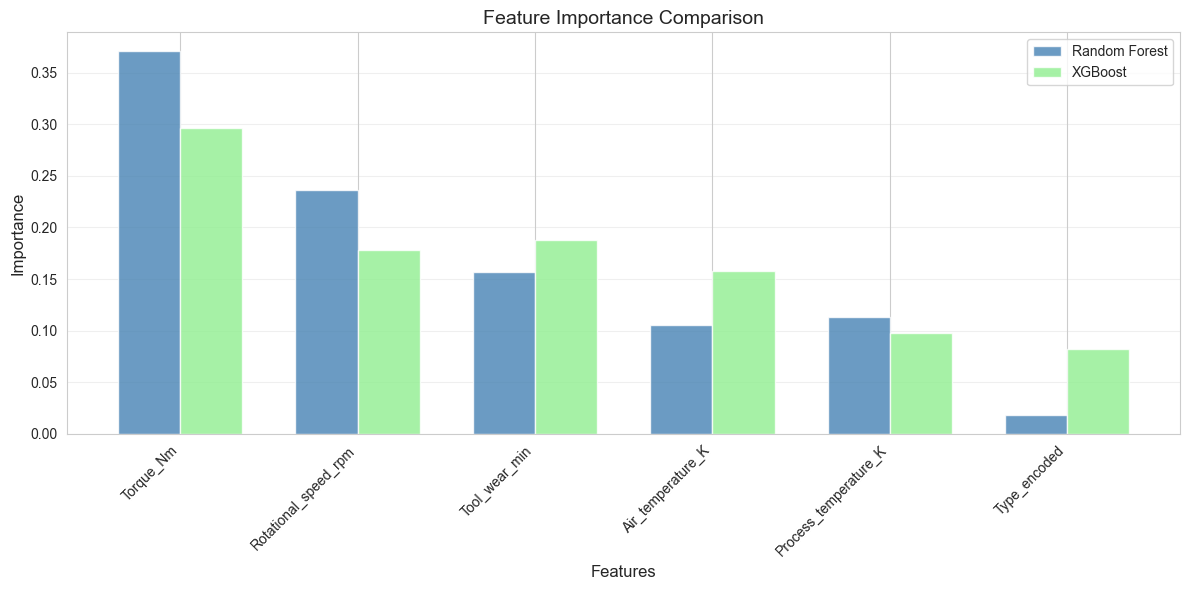

In [43]:
# Feature Importance 비교 시각화
features = importance_comparison["Feature"].values
x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width / 2,
    importance_comparison["Random Forest"].values,
    width,
    label="Random Forest",
    color="steelblue",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2,
    importance_comparison["XGBoost"].values,
    width,
    label="XGBoost",
    color="lightgreen",
    alpha=0.8,
)

ax.set_xlabel("Features", fontsize=12)
ax.set_ylabel("Importance", fontsize=12)
ax.set_title("Feature Importance Comparison", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 결론 및 인사이트

1. 데이터 특성
   - 전체 샘플 수: 10,000개
   - 고장률: 3.39%
   - 클래스 불균형 비율: 1:28.5

2. 주요 고장 유형
   - HDF: 115건
   - OSF: 98건
   - PWF: 95건

3. 모델 성능 (테스트 데이터)
   - Random Forest F1-Score: 0.6789
   - XGBoost F1-Score: 0.8099

4. 가장 중요한 특성 Top 3
   - Torque_Nm: 0.333
   - Rotational_speed_rpm: 0.207
   - Tool_wear_min: 0.172

5. 개선 방향
   - 클래스 불균형 처리 (SMOTE, Class weight 조정 등)
   - 하이퍼파라미터 튜닝
   - Feature Engineering (온도차, 속도-토크 비율 등)
   - 딥러닝 모델 적용 (2일차 실습)

## 💡 실습 과제

1. **Feature Engineering**: 새로운 특성 생성
   - 온도차이 (Process temp - Air temp)
   - Power (Rotational speed × Torque)
   - 이러한 특성들이 모델 성능을 개선하는지 확인

2. **클래스 불균형 처리**:
   - RandomForestClassifier의 `class_weight='balanced'` 옵션 사용
   - XGBClassifier의 `scale_pos_weight` 파라미터 사용
   - SMOTE를 사용한 오버샘플링

In [44]:
# ===== 1. 준비 =====
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, average_precision_score, roc_auc_score
from xgboost import XGBClassifier

# df: 기존에 로드/전처리한 데이터프레임을 사용한다고 가정
# 타깃과 피처 컬럼명 (노트북에서 쓰신 이름에 맞춰주세요)
TARGET = "Machine failure"                 # 예: 'Machine failure'를 언더스코어로 바꿔 쓰셨다면 이렇게
BASE_FEATS = [
    "Type",                                # 범주형
    "Air_temperature_K",
    "Process_temperature_K",
    "Rotational_speed_rpm",
    "Torque_Nm",
    "Tool_wear_min",
]

# ===== 2. 특성 공학 =====
df_fe = df.copy()

# (1) ΔT = 공정온도 - 공기온도
df_fe["Delta_T"] = df_fe["Process_temperature_K"] - df_fe["Air_temperature_K"]

# (2) Power 유사항 = 토크 × 회전속도
df_fe["Power_like"] = df_fe["Torque_Nm"] * df_fe["Rotational_speed_rpm"]

# (3) 마모 당 파워 = (작은 값으로 나눗셈 폭주 방지)
df_fe["Power_per_wear"] = df_fe["Power_like"] / (df_fe["Tool_wear_min"] + 1e-6)

# (4) 온도비
df_fe["Proc_to_Air_T_ratio"] = df_fe["Process_temperature_K"] / (df_fe["Air_temperature_K"] + 1e-6)

ENGINEERED = BASE_FEATS + ["Delta_T", "Power_like", "Power_per_wear", "Proc_to_Air_T_ratio"]

X = df_fe[ENGINEERED].copy()
y = df_fe[TARGET].astype(int).values

# ===== 3. 전처리 파이프라인 (범주형/수치형 분리) =====
cat_cols = ["Type"]
num_cols = [c for c in ENGINEERED if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
)

# ===== 4. 베이스라인(XGB) 파이프라인 + CV 평가 =====
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.06,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline([("prep", preprocess), ("clf", xgb)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1": make_scorer(f1_score),
    "roc_auc": make_scorer(roc_auc_score, needs_threshold=True),
    "pr_auc": make_scorer(average_precision_score, needs_threshold=True),
}

cv_res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)
print(
    f"[Feature Eng. + XGB | 5-fold]\n"
    f"F1    : {cv_res['test_f1'].mean():.3f} ± {cv_res['test_f1'].std():.3f}\n"
    f"ROC-AUC: {cv_res['test_roc_auc'].mean():.3f} ± {cv_res['test_roc_auc'].std():.3f}\n"
    f"PR-AUC : {cv_res['test_pr_auc'].mean():.3f} ± {cv_res['test_pr_auc'].std():.3f}"
)


[Feature Eng. + XGB | 5-fold]
F1    : 0.788 ± 0.025
ROC-AUC: nan ± nan
PR-AUC : nan ± nan
